# Computer Vision
## Exercise Sheet 3: Image Center, Edges, Keypoints
### Erhardt Barth / Philipp Gruening / Christoph Linse / Manuel Laufer
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{barth, gruening, linse, laufer} @inb.uni-luebeck.de*

## Note: Please insert the names of all participating students:

1. Hauke Budig
2. Hannah Lueck
3. Max-Ole von Waldow
4. Alissa Kovalenko
5.


In [ ]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import dilation
import math

%matplotlib inline

## Exercise 3.1
### Finding the Image Center
Camera calibration refers to the process of computing the intrinsic and extrinsic parameters of the camera. It is a necessary step in many computer vision applications such as 3D scene reconstruction and recognition. One important intrinsic parameter is the image center. Print out the images `ueb311.jpg` and `ueb312.jpg` and estimate the image centers by using a ruler.

**Hint**: Make small printouts of the images to have enough space around them.

In [ ]:
def load_image_gray(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image

In [ ]:
def load_image_gray_normalized(image_path):
    return load_image_gray(image_path).astype('float32')/255.

'\nImage Center is in: 660x350\n'

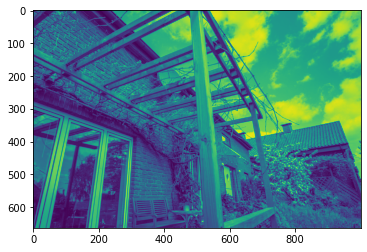

In [ ]:
def gradient(image):
    v = .5
    k_y = np.zeros((3, 3))
    k_y[0, 1] = -v
    k_y[2, 1] = +v

    k_x = np.zeros((3, 3))
    k_x[1, 0] = -v
    k_x[1, 2] = +v

    image = np.copy(image).astype('float32')

    gradient_x = cv2.filter2D(image, -1, k_x)
    gradient_y = cv2.filter2D(image, -1, k_y)

    return gradient_x, gradient_y

#img_1 = load_image_gray(r'/content/cs4250/data/exercise_3/ueb311.jpg')
#plt.imshow(img_1)
img_2 = load_image_gray(r'/content/cs4250/data/exercise_3/ueb312.jpg')
plt.imshow(img_2)
"""
Image Center is in: 660x350
"""

## Exercise 3.2.1
### Edge Detection
Open the image `ueb32.jpg` in Python and show the image gradients $d_x$ and $d_y$. Compute the magnitude of gradients image and apply a threshold to retain only the edges of the object. For those edges, compute and show the gradient angle image (`np.arctan2`). How can you tell the angle of the gradient from looking only at the gradients?

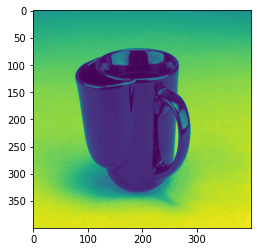

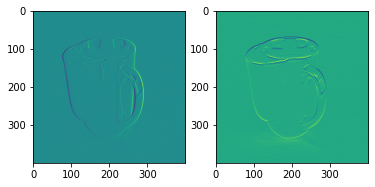

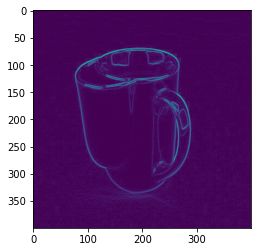

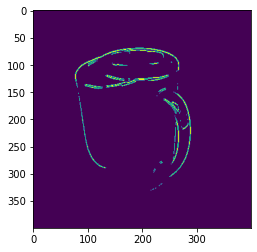

min angle: {np.amin(angle[x,y])}
 max angle: {np.amax(angle[x,y])}


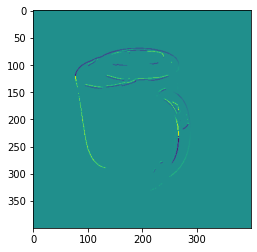

In [ ]:
# load image
plt.figure
img = load_image_gray(r'/content/cs4250/data/exercise_3/ueb32.jpg')
plt.subplot(1,1,1)
plt.imshow(img)
plt.show()

# smooth image
averageBlur = cv2.GaussianBlur(img, (7, 7), sigmaX=.1, sigmaY=.1)
plt.imshow(averageBlur)
# compute and show gradient images
# make images comparable
gradient_x, gradient_y = gradient(averageBlur)

x_max = np.amax(gradient_x)
y_max = np.amax(gradient_y)

for i in range(len(gradient_x)):
  gradient_x[i]= gradient_x[i]/x_max
  gradient_y[i] = gradient_y[i]/y_max

plt.subplot(1, 2, 1)
plt.imshow(gradient_x)
plt.subplot(1, 2, 2)
plt.imshow(gradient_y)
plt.show()

# compute gradient magnitude

magnitude = np.zeros((gradient_x.shape[0], gradient_x.shape[1]))
edges = np.zeros((gradient_x.shape[0], gradient_x.shape[1]))

for x in range(gradient_x.shape[0]):
  for y in range(gradient_x.shape[1]):
    magnitude[x,y] = np.sqrt(gradient_x[x,y]**2 + gradient_y[x,y]**2)
    if magnitude[x,y] >= 0.45:
      edges[x,y] = 1

plt.imshow(magnitude)
plt.show()

plt.imshow(edges)
plt.show()

# compute an angle image that should be in range [-180,+180]
# show angles only for real edges
edg_nonzero = np.nonzero(edges)

angle = np.zeros((gradient_x.shape[0], gradient_x.shape[1]))
"""
for x in range(gradient_x.shape[0]):
  for y in range(gradient_x.shape[1]):
    if edg_nonzero[x,y]:"""
for i in range(len(edg_nonzero[0])):
  x, y = edg_nonzero[0][i], edg_nonzero[1][i]
  angle[x,y] = math.degrees( np.arctan2(gradient_y[x,y], gradient_x[x,y]) )

print("min angle: {np.amin(angle[x,y])}\n max angle: {np.amax(angle[x,y])}")

plt.imshow(angle)
plt.show()



## Exercise 3.2.2
### Canny Edge Detector
Open the image `ueb32.jpg` in Python and use the OpenCV Canny algorithm to find the edges in the image.
Compare the result with the magnitude of gradient image. Display both results side by side using `plt.subplots`.
Comment on how the two results differ and why.

uint8
maximum value: 223.0
float64


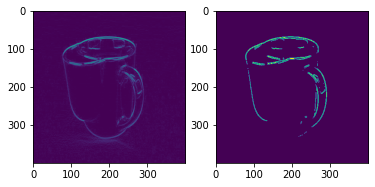

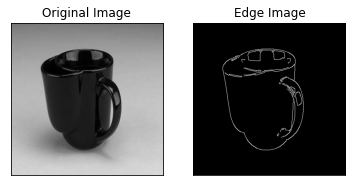

In [ ]:
# load image
img = cv2.imread("./data/exercise_3/ueb32.jpg")


# convert image to grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY )
# normalize
print(img_gray.dtype)
img_float = img_gray.astype('float64')
print("maximum value:", np.amax(img_float))
print(img_float.dtype)
img_norm = img_float/255.0
# compute magnitude of gradient image

gradient_x, graadient_y = gradient(img_norm)

for i in range(len(gradient_x)):
  gradient_x[i]= gradient_x[i]/x_max
  gradient_y[i] = gradient_y[i]/y_max

for x in range(gradient_x.shape[0]):
  for y in range(gradient_y.shape[0]):
    magnitude[x,y] = np.sqrt(gradient_x[x,y]**2 + gradient_y[x,y]**2)
    if magnitude[x,y] >= 0.45:
      edges[x,y] = 1
plt.subplot(1,2,1)
plt.imshow(magnitude)
plt.subplot(1,2,2)
plt.imshow(edges)
plt.show()

# apply canny
edges = cv2.Canny(img,100,200)
plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()
# compare results

## Exercise 3.3
### Key Point Detection
Implement the following key-point detectors:
* local maxima of $K$
* local maxima of $K$ − $\alpha$ $H^2$, with $\alpha$ as weighting parameter

The function is supposed to return images of the same size as the input, where the pixels contain $K$ or $K$ − $\alpha$ $H^2$.

$K$ and $H$ should be the invariants of the structure tensor $J$ (see script).
Evaluate the detectors above on two kinds of test images: (i) the synthetic image `ueb331.npy`, (ii) the
picture `ueb332.jpg`.

Comment your results with a focus on
1. the localization of the key points
2. the influence of the $H$ term as controlled via the parameter $\alpha$.

**Question**: Why do you filter the image with a Gaussian kernel a second time? It is **not** about noise removal!

**Hint**: Use the provided functions `find_local_max` and `plot_marks`.

In [ ]:
def find_local_max(keypoints, thres=1e-6, k=3):
    kernel = np.ones((k, k))
    kernel[k//2, k//2] = 0
    local_max = keypoints > thres + dilation(keypoints, kernel)

    return local_max

In [ ]:
def plot_marks(map, ax=None):
    if ax is None:
        _, ax = plt.subplots(1)
    col, row = np.nonzero(map)

    ax.plot(row, col, 'r.')

In [ ]:
def key_points_structure(image, alpha, sigma=.1):
    # image parameters

    # 0. filter with Gaussian kernel with sigma
    averageBlur = cv2.GaussianBlur(image, (0, 0), sigmaX=sigma, sigmaY=sigma)

    # 1. partial derivatives
    gradient_x, gradient_y = gradient(averageBlur)

    # 3. filter with gaussian kernel with sigma = 1
    x_quad_blur = cv2.GaussianBlur(gradient_x**2, (0, 0), sigmaX=1, sigmaY=1)
    y_quad_blur = cv2.GaussianBlur(gradient_y**2, (0, 0), sigmaX=1, sigmaY=1)
    xy_blur = cv2.GaussianBlur(gradient_x * gradient_y, (0, 0), sigmaX=1, sigmaY=1)

    # 2. product images
    """
    J_beforeIntegral = np.array([ [np.multiply(gradient_x, gradient_x), np.multiply(gradient_x, gradient_y)],
                                  [np.multiply(gradient_x, gradient_y), np.multiply(gradient_y, gradient_y)] ])"""
    """
    J_beforeIntegral = np.zeros((gradient_x.shape[0]*2, gradient_x.shape[1]*2))
    J_beforeIntegral[0:gradient_x.shape[0], 0:gradient_x.shape[1]] = np.multiply(gradient_x, gradient_x)
    J_beforeIntegral[0:gradient_x.shape[0], gradient_x.shape[1]:] = np.multiply(gradient_x, gradient_y)
    J_beforeIntegral[gradient_x.shape[0]:, 0:gradient_x.shape[1]] = np.multiply(gradient_x, gradient_y)
    J_beforeIntegral[gradient_y.shape[0]:, gradient_y.shape[1]:] = np.multiply(gradient_y, gradient_y)"""

    J = np.zeros((gradient_x.shape[0]*2, gradient_x.shape[1]*2))
    H = np.zeros((gradient_x.shape[0], gradient_x.shape[1]))
    K = np.zeros((gradient_x.shape[0], gradient_x.shape[1]))
    for x in range(gradient_x.shape[0]):
      for y in range(gradient_x.shape[1]):
        localJ =  np.array( [ [x_quad_blur[x,y] , xy_blur[x,y]      ],
                              [xy_blur[x,y]     , y_quad_blur[x,y]  ] ])
        #J[x*2:x*2+2, y*2:y*2+2] = localJ
        # 4. compute invarians for J
        eigval, eigvec = np.linalg.eig(localJ)
        localH = np.real(min(eigval) + max(eigval))
        localK = np.real(min(eigval) * max(eigval))
        H[x,y] = localH
        K[x,y] = localK


    K_minus_H = K - alpha * np.multiply(H,H)

    # return K, K_minus_H
    return K, K_minus_H

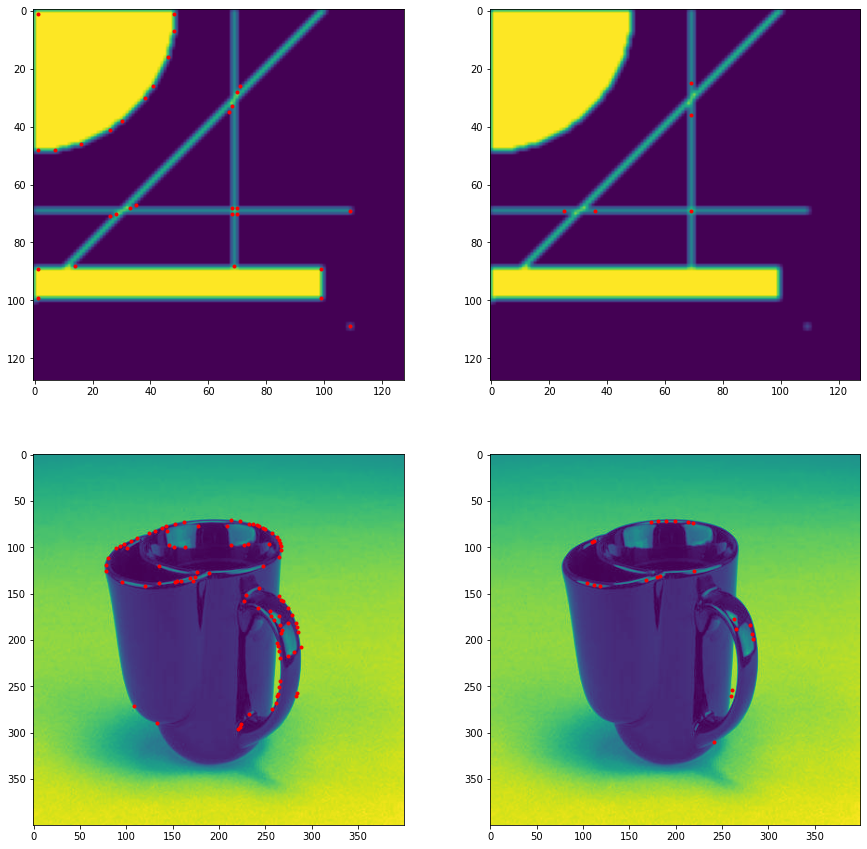

In [ ]:
# define alpha, sigma, and k
alpha, sigma, k = 2, 0.1, 3

# load images
image = np.load("./data/exercise_3/ueb331.npy")
# load image
image2 = cv2.imread("./data/exercise_3/ueb332.jpg")
image2_gray = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY )
img2_float = image2_gray.astype('float64')
img2_norm = img2_float/255.0

# extract keypoints
keypoints_K, keypoints_K_minus_H = key_points_structure(image, alpha, sigma)
keypoints2_K, keypoints2_K_minus_H = key_points_structure(img2_norm, alpha, sigma)

# show found keypoints (K, K_minus_H) for both images
_, ax = plt.subplots(2, 2, figsize=(15, 15))

bestKeyPoints_K = find_local_max(keypoints_K, k=k)
ax[0][0].imshow(image)
plot_marks(bestKeyPoints_K, ax[0][0])

bestKeyPoints_H = find_local_max(keypoints_K_minus_H, k=k)
ax[0][1].imshow(image)
plot_marks(bestKeyPoints_H, ax[0][1])

bestKeyPoints_K = find_local_max(keypoints2_K, k=k)
ax[1][0].imshow(img2_norm)
plot_marks(bestKeyPoints_K, ax[1][0])

bestKeyPoints_H = find_local_max(keypoints2_K_minus_H, k=k)
ax[1][1].imshow(img2_norm)
plot_marks(bestKeyPoints_H, ax[1][1])